In [1]:
import rasterio
import uuid
import pickle
import numpy as np
import pandas as pd
import netCDF4 as nc
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from rasterio.windows import from_bounds
from datetime import datetime, timedelta

In [2]:
def daily_aggregate(files, var_name, method):
    """
    Compute daily aggregated values (max, min, mean, or sum) across multiple NetCDF files.

    Parameters
    ----------
    files : list of str
        List of NetCDF file paths.
    var_name : str, optional
        Variable to aggregate.
    method : str, optional
        Aggregation method: "max", "min", "mean", "sum".

    Returns
    -------
    dict
        Dictionary containing 'time', 'latitude', 'longitude', and the aggregated variable.
    """
    if method not in {"max", "min", "mean", "sum"}:
        raise ValueError("method must be one of: 'max', 'min', 'mean', 'sum'")

    all_data = []
    all_times = []

    for f in files:
        with nc.Dataset(f) as ds:
            data = ds.variables[var_name][:]
            time_var = ds.variables["valid_time"]
            time_units = getattr(time_var, "units", "seconds since 1970-01-01 00:00:00")
            times = nc.num2date(time_var[:], units=time_units)

            all_data.append(data)
            all_times.append(times)

            # Assume lat/lon are identical across files
            if 'lats' not in locals():
                lats = ds.variables["latitude"][:]
                lons = ds.variables["longitude"][:]

    # Concatenate along time axis
    all_data = np.concatenate(all_data, axis=0)
    all_times = np.concatenate(all_times, axis=0)

    # --- Group by day
    days = np.array([datetime(t.year, t.month, t.day) for t in all_times])
    unique_days = np.unique(days)

    daily_vals = np.empty((len(unique_days), len(lats), len(lons)), dtype=np.float32)

    for i, day in enumerate(unique_days):
        mask = days == day
        if method == "max":
            daily_vals[i] = np.nanmax(all_data[mask], axis=0)
        elif method == "min":
            daily_vals[i] = np.nanmin(all_data[mask], axis=0)
        elif method == "mean":
            daily_vals[i] = np.nanmean(all_data[mask], axis=0)
        elif method == "sum":
            daily_vals[i] = np.nansum(all_data[mask], axis=0)
    
    # z-scale daily_vals
    daily_vals = (daily_vals - daily_vals.mean()) / daily_vals.std()

    # --- Unique dummy name ensures no collision
    dummy_name = f"inmemory_{uuid.uuid4().hex}"
    out_ds = nc.Dataset(dummy_name, mode="w", diskless=True, persist=False, format="NETCDF4")

    # Dimensions
    out_ds.createDimension("valid_time", len(unique_days))
    out_ds.createDimension("latitude", len(lats))
    out_ds.createDimension("longitude", len(lons))

    # Variables
    time_out = out_ds.createVariable("valid_time", "i4", ("valid_time",))
    lat_out = out_ds.createVariable("latitude", "f4", ("latitude",))
    lon_out = out_ds.createVariable("longitude", "f4", ("longitude",))
    var_out = out_ds.createVariable(var_name, "f4", ("valid_time", "latitude", "longitude"), zlib=True)

    # Assign values
    lat_out[:] = lats
    lon_out[:] = lons
    time_out[:] = nc.date2num(unique_days, units="days since 1970-01-01 00:00:00", calendar="gregorian")
    time_out.units = "days since 1970-01-01 00:00:00"
    var_out[:] = daily_vals

    # Metadata
    out_ds.description = f"Daily {method} of {var_name}"
    out_ds.history = f"Created in-memory on {datetime.utcnow().isoformat()}"

    return out_ds

In [3]:
filelist = [f'summer_school_25/climate/2m_temperature/{y}.nc' for y in range(2015,2025)]
t2m_max = daily_aggregate(filelist, 't2m', 'max')
t2m_min = daily_aggregate(filelist, 't2m', 'min')

filelist = [f'summer_school_25/atmo/dust_aerosol_optical_depth_550nm/{y}.nc' for y in range(2015,2025)]
dust = daily_aggregate(filelist,'duaod550', 'sum')


In [5]:
t2m_max['t2m'][:].std()

1.0000002

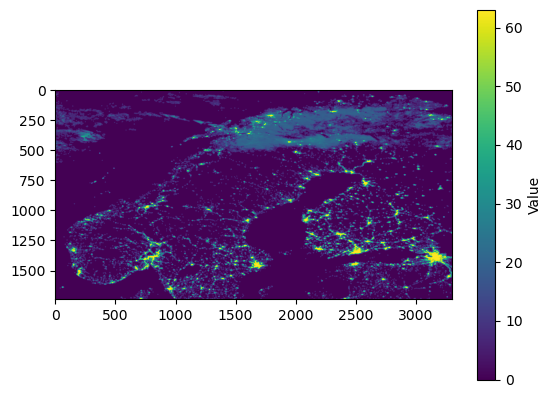

In [6]:
file_path = "summer_school_25/Night_Time_Lights_(NTL)/gDMSP_VIIRS_Monthly_Weighted_2022.tif"
min_lon, min_lat = 4.0, 57.0
max_lon, max_lat = 31.5, 71.5

with rasterio.open(file_path) as src:
    # Convert bounding box to raster row/col indices
    window = from_bounds(min_lon, min_lat, max_lon, max_lat, transform=src.transform)
    
    # Read only the window
    data = src.read(1, window = window)
    
    # Optional: update the transform for the subset
    transform = src.window_transform(window)

    profile = src.profile  # metadata, CRS, transform, etc.

#data_small = data[::100, ::100]
plt.imshow(data, cmap='viridis', origin='upper')
plt.colorbar(label='Value')
plt.show()

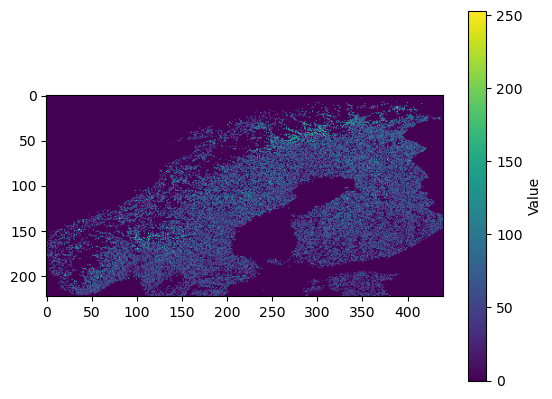

In [7]:
file_path = "summer_school_25/treeCover/HRL_TreeCoverDensity_2018.tif"
min_lon, min_lat = 4.0, 57.0
max_lon, max_lat = 31.5, 71.5

with rasterio.open(file_path) as src:
    # Convert bounding box to raster row/col indices
    window = from_bounds(min_lon, min_lat, max_lon, max_lat, transform=src.transform)
    
    # Read only the window
    data = src.read(1, window = window)
    
    # Optional: update the transform for the subset
    transform = src.window_transform(window)

    profile = src.profile  # metadata, CRS, transform, etc.

data_small = data[::100, ::100]
plt.imshow(data_small, cmap='viridis', origin='upper')
plt.colorbar(label='Value')
plt.show()

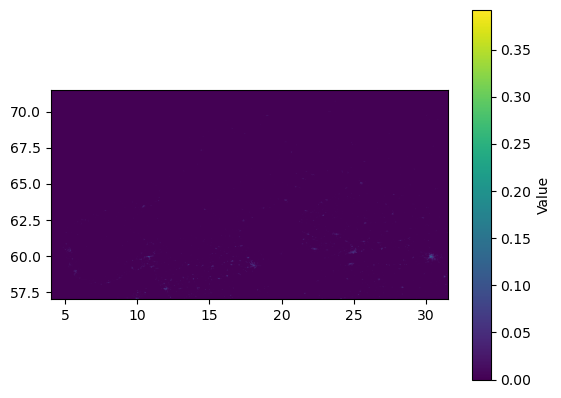

In [8]:
file_path = "summer_school_25/wsf/WSF3D_V02_BuildingFraction.tif"
min_lon, min_lat = 4.0, 57.0
max_lon, max_lat = 31.5, 71.5

with rasterio.open(file_path) as src:
    # Convert bounding box to raster row/col indices
    window = from_bounds(min_lon, min_lat, max_lon, max_lat, transform=src.transform)
    
    # Read only the window
    wsf = src.read(1, window=window)
    
    # Optional: update the transform for the subset
    transform_wsf = src.window_transform(window)
    
    profile = src.profile  # metadata, CRS, transform, etc.

wsf = np.abs((wsf-255)/255)
wsf = np.where(wsf > 0, wsf, 0)  # keep only positive

wsf_extent = [min_lon, max_lon, min_lat, max_lat]

data_small = wsf[::10, ::10]
plt.imshow(data_small, cmap='viridis', extent=wsf_extent, origin='upper')
plt.colorbar(label='Value')
plt.show()


In [9]:
flat = wsf.ravel()
weights = flat / flat.sum()  # probabilities
n_samples = 16000
chosen_idx = np.random.choice(len(flat), size=n_samples, replace=True, p=weights)
rows, cols = np.unravel_index(chosen_idx, wsf.shape)
xs, ys = rasterio.transform.xy(transform_wsf, rows, cols)
gdf_subject = gpd.GeoDataFrame(
    geometry=[Point(x, y) for x, y in zip(xs, ys)],
    crs=src.crs
)

# path to border shapefile
shapefile_path = "summer_school_25/shape_borders/ne_110m_admin_0_countries.shp"

world = gpd.read_file(shapefile_path)
nordic_countries = ["Sweden", "Norway", "Finland", "Denmark"]
nordic = world[world["NAME"].isin(nordic_countries)]

# Ensure both GeoDataFrames use the same CRS
nordic = nordic.to_crs(gdf_subject.crs)

# Perform a spatial join to find points within the Nordic countries
gdf_subject = gpd.sjoin(gdf_subject, nordic, how="inner", predicate="within")
n_samples = 10000
gdf_subject = gdf_subject.head(10000)
gdf_subject.shape

(10000, 170)

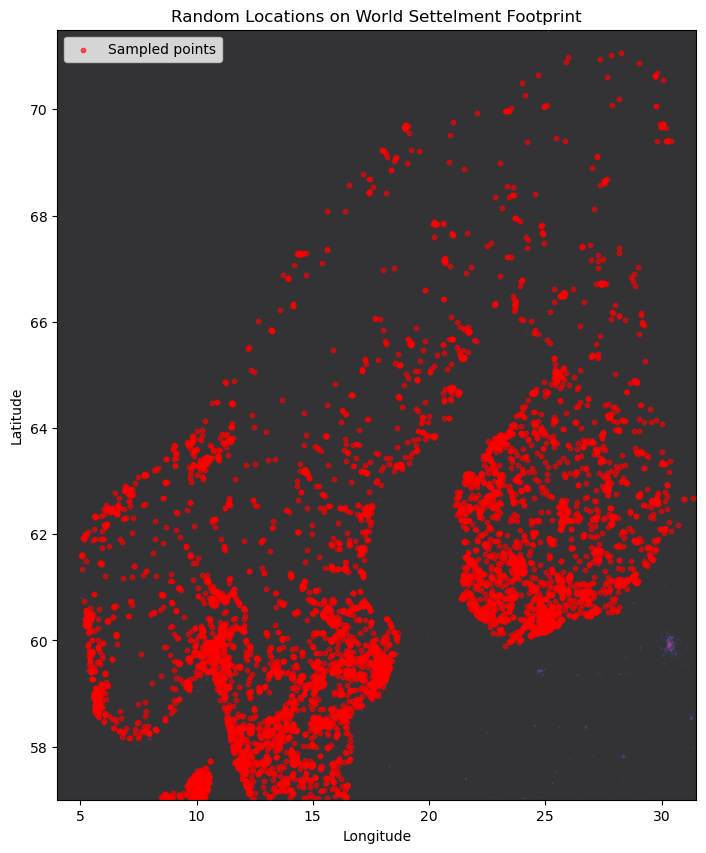

In [10]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 10))

# Plot raster
ax.imshow(data_small, cmap="inferno", extent=wsf_extent,alpha=0.8)

# Overlay points
gdf_subject.plot(ax=ax, color="red", markersize=10, alpha=0.6, label="Sampled points")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Random Locations on World Settelment Footprint")
ax.legend()
plt.show()

In [11]:
# Example: start and end timestamps
start_date = pd.Timestamp("2018-01-01")
end_date   = pd.Timestamp("2024-12-30")

# Generate random integers between start and end
random_days = np.random.randint(0, (end_date - start_date).days + 1, n_samples)

# Convert to dates
gdf_subject["date"] = start_date + pd.to_timedelta(random_days, unit="D")
gdf_subject["subID"] = range(1,n_samples+1)
gdf_subject

,geometry,index_right,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,...,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,date,subID
0,POINT (22.10783 61.53861),151,Admin-0 country,1,3,Finland,FI1,1,2,Country,...,None,None,None,None,None,None,None,None,2019-06-15,1
1,POINT (11.3885 59.11894),110,Admin-0 country,1,3,Sweden,SWE,0,2,Sovereign country,...,None,None,None,None,None,None,None,None,2018-11-28,2
3,POINT (28.9445 61.87072),151,Admin-0 country,1,3,Finland,FI1,1,2,Country,...,None,None,None,None,None,None,None,None,2024-02-04,3
5,POINT (15.99139 59.51639),110,Admin-0 country,1,3,Sweden,SWE,0,2,Sovereign country,...,None,None,None,None,None,None,None,None,2024-03-31,4
6,POINT (22.73083 60.46606),151,Admin-0 country,1,3,Finland,FI1,1,2,Country,...,None,None,None,None,None,None,None,None,2020-10-27,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14291,POINT (24.94983 60.25061),151,Admin-0 country,1,3,Finland,FI1,1,2,Country,...,None,None,None,None,None,None,None,None,2024-01-18,9996
14292,POINT (26.0045 60.48161),151,Admin-0 country,1,3,Finland,FI1,1,2,Country,...,None,None,None,None,None,None,None,None,2021-05-21,9997
14293,POINT (23.21928 60.77406),151,Admin-0 country,1,3,Finland,FI1,1,2,Country,...,None,None,None,None,None,None,None,None,2018-04-20,9998
14294,POINT (10.78106 59.66883),21,Admin-0 country,1,3,Norway,NOR,0,2,Sovereign country,...,None,None,None,None,None,None,None,None,2023-08-15,9999


In [13]:
# Open once
with rasterio.open("summer_school_25/treeCover/HRL_TreeCoverDensity_2018.tif") as src:
    raster = src.read(1)          # read raster into memory
    transform = src.transform     # affine transform for pixel->geo

xs = gdf_subject.geometry.x.to_numpy()
ys = gdf_subject.geometry.y.to_numpy()

# Convert all coords to raster row/col
shape = raster.shape
print(shape)
rows, cols = rasterio.transform.rowcol(transform, xs, ys)
rows[rows > shape[0]] = shape[0]-1
cols[cols > shape[1]] = shape[1]-1
greenness = raster[rows, cols]
greenness = (greenness - greenness.mean()) / greenness.std()

(22258, 43901)


In [15]:
def circular_mask(radius):
    """Create a circular boolean mask with given pixel radius."""
    y, x = np.ogrid[-radius:radius+1, -radius:radius+1]
    return x**2 + y**2 <= radius**2

# Example radius in pixels (e.g., 3px ~ depending on raster resolution)
radius = 30
circle = circular_mask(radius)

# Open raster
with rasterio.open("summer_school_25/treeCover/HRL_TreeCoverDensity_2018.tif") as src:
    window = from_bounds(min_lon, min_lat, max_lon, max_lat, transform=src.transform)
    raster = src.read(1, window=window)
    transform = src.window_transform(window)

shape = raster.shape
rows, cols = rasterio.transform.rowcol(transform, xs, ys)

# Clip to raster extent
rows = np.clip(rows, 0, shape[0]-1)
cols = np.clip(cols, 0, shape[1]-1)

# Convert all coords to raster row/col
#gdf['greeness'] = raster[rows, cols]

means = []
for r, c in zip(rows, cols):
    # Define local window around the point
    r0, r1 = r - radius, r + radius + 1
    c0, c1 = c - radius, c + radius + 1

    # Clip to raster boundaries
    r0, r1 = max(r0, 0), min(r1, shape[0])
    c0, c1 = max(c0, 0), min(c1, shape[1])

    patch = raster[r0:r1, c0:c1]

    # Match circular mask to actual patch size
    mask = circle[
        (r0-r+radius):(r1-r+radius),
        (c0-c+radius):(c1-c+radius)
    ]

    # Apply mask and compute mean
    vals = patch[mask]
    vals = vals[vals != src.nodata] if src.nodata is not None else vals
    means.append(np.nan if vals.size == 0 else vals.mean())

greenness = np.array(means)
greenness = (greenness - greenness.mean()) / greenness.std()

In [16]:
def get_dataOI(ds, lat, lon, variable_name, start_time, end_time):
    """
    Extracts data for a given (lat, lon) point and timeframe from a NetCDF dataset.
    
    Parameters
    ----------
    ds : netCDF4.Dataset
        The dataset object.
    lat : float
        Latitude of the desired point.
    lon : float
        Longitude of the desired point.
    start_time : datetime
        Start of the timeframe.
    end_time : datetime
        End of the timeframe.
        
    Returns
    -------
    numpy.ndarray
        1D array of data values for the selected point and timeframe.
    list of datetime
        Corresponding datetimes of the returned values.
    """
    # Extract coordinate arrays
    lats = ds.variables["latitude"][:]
    lons = ds.variables["longitude"][:]

    # Find nearest grid point
    lat_idx = np.abs(lats - lat).argmin()
    lon_idx = np.abs(lons - lon).argmin()

    # Convert valid_time to datetime
    time_var = ds.variables["valid_time"]
    time_units = time_var.units if hasattr(time_var, "units") else "seconds since 1970-01-01 00:00:00"
    times = nc.num2date(time_var[:], units=time_units)

    # Select timeframe
    mask = (times >= start_time) & (times <= end_time)
    selected_times = times[mask]

    # Extract values 
    arr = ds.variables[variable_name][mask, lat_idx, lon_idx]
    # if nan values inerpolate 
    x = np.arange(len(arr))
    # Indices of valid (non-NaN) entries
    valid = ~np.isnan(arr)
    # Linear interpolation at NaN positions
    arr[~valid] = np.interp(x[~valid], x[valid], arr[valid])

    return arr, list(selected_times)

0.0%
5.0%
10.0%
15.0%
20.0%
25.0%
30.0%
35.0%
40.0%
45.0%
50.0%
55.00000000000001%
60.0%
65.0%
70.0%
75.0%
80.0%
85.0%
90.0%
95.0%


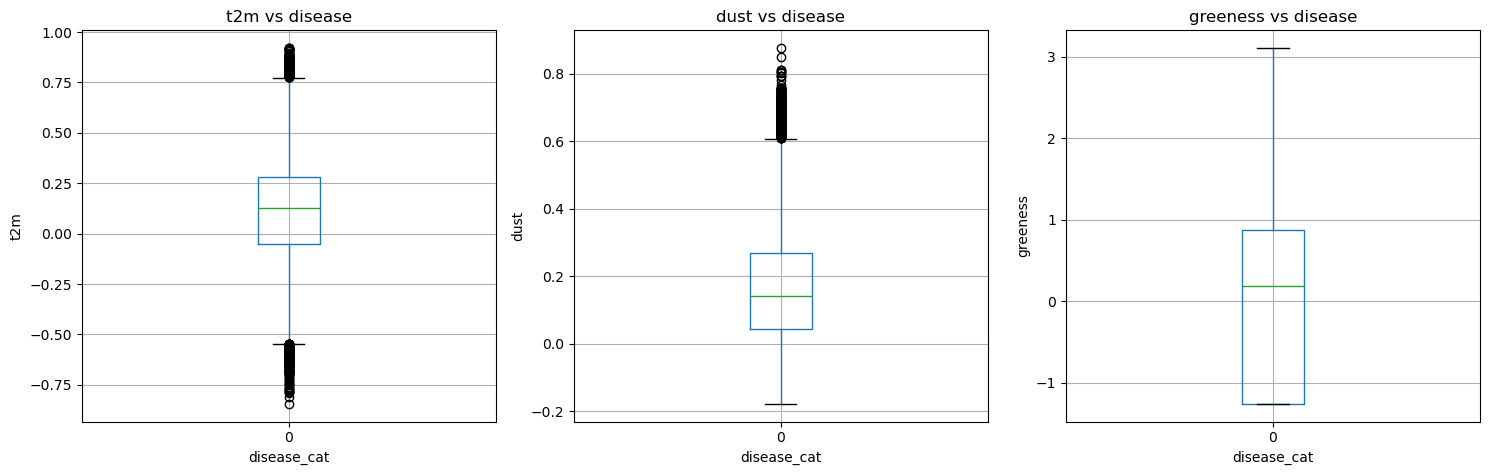

disease_cat
0    10000
Name: count, dtype: int64


In [19]:
# logistic model params
#alpha = -3.0
#beta_T = 0.05
#beta_CO = 1.5
#beta_G = 1.0

alpha = -3.0
beta_T = -1.2
beta_CO = 2
beta_G = 0.2

records = []
d = []
offset_years = 1

n = len(gdf_subject)

for i in range(n):#len(gdf_subject)):
    if i%500==0:
        print(str(100*(i/n))+'%')
    row = gdf_subject.iloc[i]
    end = row['date']
    start = row['date'] - pd.DateOffset(years=offset_years)
    co_data, co_time = get_dataOI(dust, row['geometry'].y, row['geometry'].x, 'duaod550', start, end)
    t2m_data, t2m_time = get_dataOI(t2m_min, row['geometry'].y, row['geometry'].x, 't2m', start, end)

    # there may be some missing dates in either dataset, so align them
    t2m_time = [datetime(t.year, t.month, t.day) for t in t2m_time]
    co_time = [datetime(t.year, t.month, t.day) for t in co_time]
    co_time = pd.DatetimeIndex(co_time)
    t2m_time = pd.DatetimeIndex(t2m_time)
    common_dates = co_time.isin(t2m_time)
    co_data = co_data[common_dates]
    common_dates = t2m_time.isin(co_time)
    t2m_data = t2m_data[common_dates]

    # calculate daily probabilities
    logit = alpha + beta_T*(t2m_data) + beta_CO*(co_data) - beta_G*greenness[i]
    prob = 1/(1+np.exp(-logit))
    
    # simulate binary disease outcome
    disease = np.random.binomial(1, prob)
    
    df_i = pd.DataFrame({
        "id": row['subID'],
        "disease": disease,
        "t2m": t2m_data,
        "co": co_data,  
        "greenness": greenness[i],
        "date": row['date']
    })
    records.append(df_i)
    #print(np.sum(df_i['disease']==1))
    d.append(np.sum(df_i['disease']==1))

records_out = []

for i, df_i in enumerate(records):
    coord = gdf_subject.geometry.iloc[i]
    date = gdf_subject.date.iloc[i]
    id_ = df_i.id.iloc[0]
    d = df_i.disease.sum()
    t2m__ = (df_i.t2m).mean()
    co__ = df_i.co.mean()
    g = df_i.greenness.iloc[0]
    records_out.append([id_, d, date, t2m__, co__, g, coord])

gdf = gpd.GeoDataFrame(records_out, columns=["id", "disease", "date", "t2m", "dust", "greeness", "geometry"], crs=gdf_subject.crs)
gdf

# boxplots disease value greater or smaller 100 against t2m, dust, greeness
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
gdf["disease_cat"] = np.where(gdf["disease"] > 180, 1, 0)
gdf.boxplot(column="t2m", by="disease_cat", ax=axs[0])
axs[0].set_title("t2m vs disease")
axs[0].set_ylabel("t2m")
gdf.boxplot(column="dust", by="disease_cat", ax=axs[1])
axs[1].set_title("dust vs disease")
axs[1].set_ylabel("dust")
gdf.boxplot(column="greeness", by="disease_cat", ax=axs[2])
axs[2].set_title("greeness vs disease")
axs[2].set_ylabel("greeness")
plt.suptitle("")
plt.tight_layout()
plt.show()
print(gdf.disease_cat.value_counts())

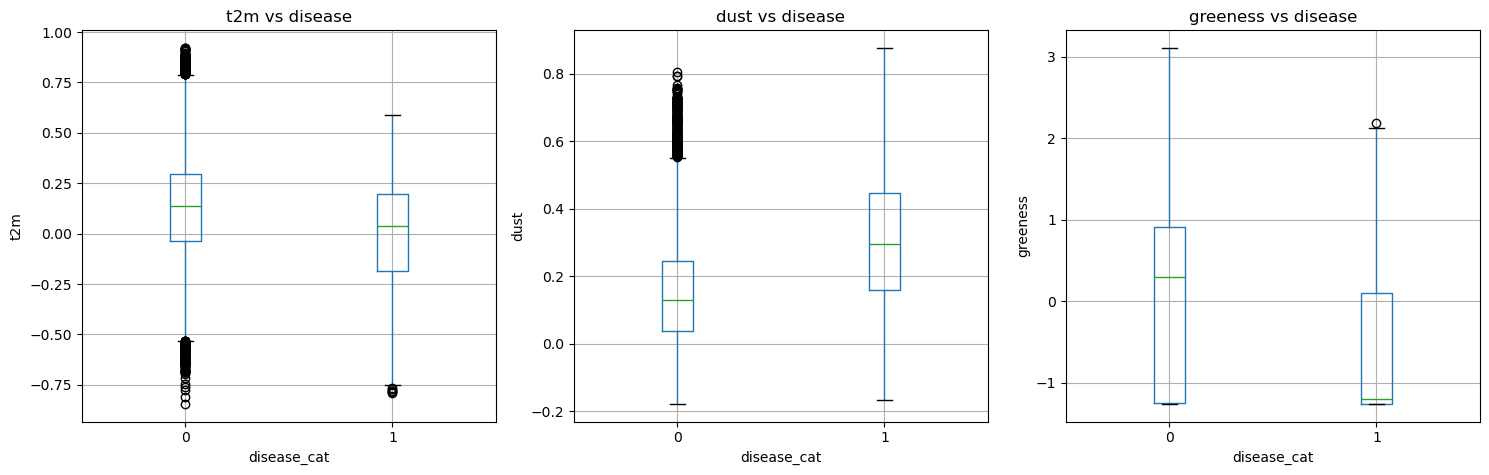

disease_cat
0    8950
1    1050
Name: count, dtype: int64


In [20]:
# boxplots disease value greater or smaller 100 against t2m, dust, greeness
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
gdf["disease_cat"] = np.where(gdf["disease"] > 50, 1, 0)
gdf.boxplot(column="t2m", by="disease_cat", ax=axs[0])
axs[0].set_title("t2m vs disease")
axs[0].set_ylabel("t2m")
gdf.boxplot(column="dust", by="disease_cat", ax=axs[1])
axs[1].set_title("dust vs disease")
axs[1].set_ylabel("dust")
gdf.boxplot(column="greeness", by="disease_cat", ax=axs[2])
axs[2].set_title("greeness vs disease")
axs[2].set_ylabel("greeness")
plt.suptitle("")
plt.tight_layout()
plt.show()
print(gdf.disease_cat.value_counts())

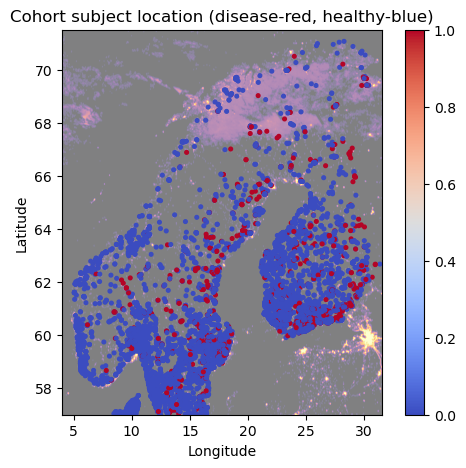

In [22]:
# drop column disease from gdf
gdf_cohort = gdf.drop(columns=["disease","t2m","dust","greeness"])
gdf_cohort

file_path = "summer_school_25/Night_Time_Lights_(NTL)/gDMSP_VIIRS_Monthly_Weighted_2022.tif"
min_lon, min_lat = 4.0, 57.0
max_lon, max_lat = 31.5, 71.5
wsf_extent = [min_lon, max_lon, min_lat, max_lat]

with rasterio.open(file_path) as src:
    # Convert bounding box to raster row/col indices
    window = from_bounds(min_lon, min_lat, max_lon, max_lat, transform=src.transform)
    
    # Read only the window
    data = src.read(1, window = window)
    
    # Optional: update the transform for the subset
    transform = src.window_transform(window)

    profile = src.profile  # metadata, CRS, transform, etc.

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))

# Raster
ax.imshow(data, cmap="inferno", extent=wsf_extent, alpha=0.5)

# Punkte mit Legende von GeoPandas
gdf_cohort.plot(ax=ax, column='disease_cat', cmap='coolwarm', markersize=7, legend=True)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Cohort subject location (disease-red, healthy-blue)")

# Kein ax.legend() nötig!
plt.show()


In [26]:
# Save to pickle file
with open("simulated_data.pkl", "wb") as f:
    pickle.dump(records, f)

# Save to pickle file
with open("gdf_subject.pkl", "wb") as f:
    pickle.dump(gdf_subject, f)

# Load it back
with open("simulated_data.pkl", "rb") as f:
    test = pickle.load(f)


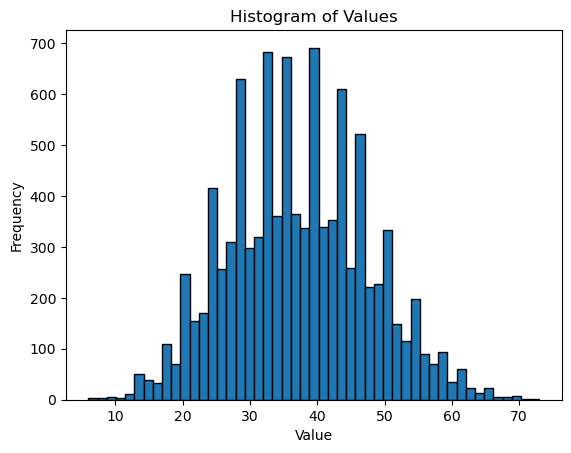

In [28]:
plt.hist(gdf["disease"], bins='auto', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Values")
plt.show()

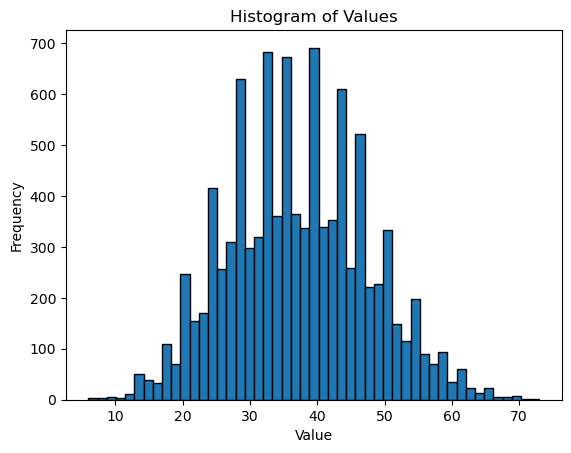

In [29]:
plt.hist(gdf["disease"], bins='auto', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Values")
plt.show()

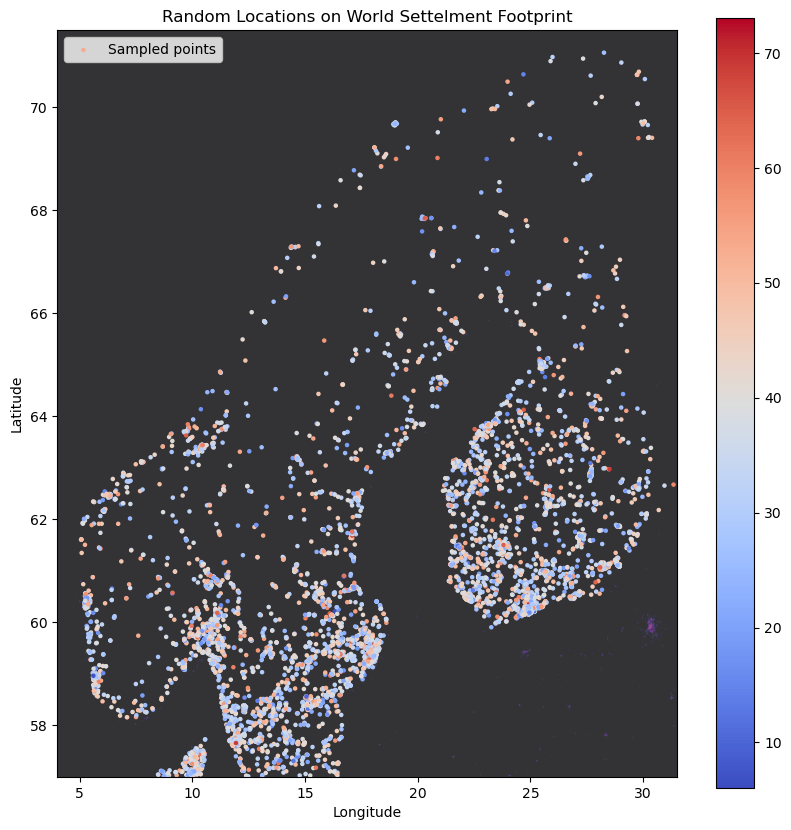

In [30]:
gdf_subject_tmp = gdf_subject.head(n).copy()
gdf_subject_tmp['disease'] = gdf["disease"]
#dd = [x+50 if x>40 else x for x in d]

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 10))

# Plot raster
ax.imshow(data_small, cmap="inferno", extent=wsf_extent,alpha=0.8)

# Overlay points with gdf_subject['disease'] as weight for the color of the points
gdf_subject_tmp.plot(ax=ax, column='disease', cmap='coolwarm', markersize=5, legend=True, label="Sampled points")
#gdf_subject.plot(ax=ax, color="red", markersize=10, alpha=0.6, label="Sampled points")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Random Locations on World Settelment Footprint")
ax.legend()
plt.show()

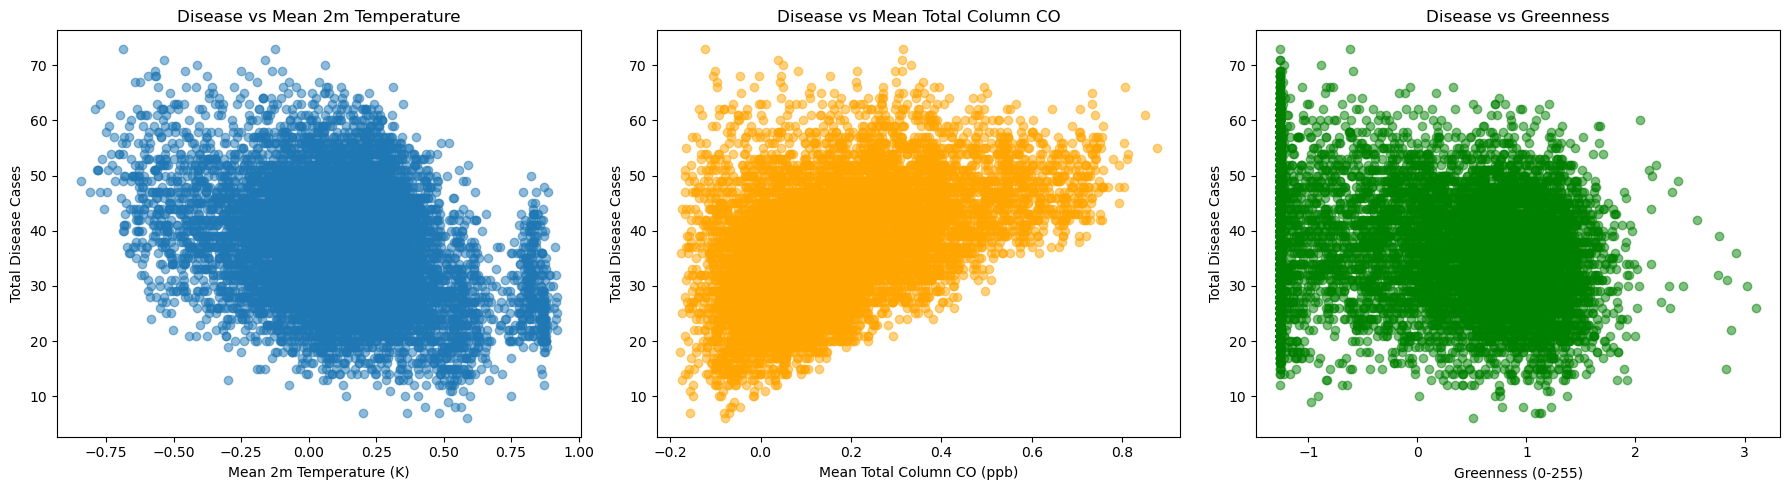

In [31]:
res = np.zeros((n,5))
i = 0
for df_i in records:
    id = df_i.id.iloc[0]
    d = df_i.disease.sum()
    t2m__ = (df_i.t2m).mean()
    co__ = df_i.co.mean()
    g = df_i.greenness.iloc[0]
    res[i] = [id, d, t2m__, co__, g]
    i += 1
df = pd.DataFrame(res, columns=['id', 'disease', 't2m', 'co', 'greenness'])

# make scatterplot for each variable against disease
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].scatter(df['t2m'], df['disease'], alpha=0.5)
axs[0].set_xlabel('Mean 2m Temperature (K)')
axs[0].set_ylabel('Total Disease Cases')
axs[0].set_title('Disease vs Mean 2m Temperature')
axs[1].scatter(df['co'], df['disease'], alpha=0.5, color='orange')
axs[1].set_xlabel('Mean Total Column CO (ppb)')
axs[1].set_ylabel('Total Disease Cases')
axs[1].set_title('Disease vs Mean Total Column CO')
axs[2].scatter(df['greenness'], df['disease'], alpha=0.5, color='green')
axs[2].set_xlabel('Greenness (0-255)')
axs[2].set_ylabel('Total Disease Cases')
axs[2].set_title('Disease vs Greenness')
plt.tight_layout()
plt.show()


In [41]:
df_i

,id,disease,t2m,co,greenness,date
0,250,1,-0.246982,1.687397,-0.984393,2023-01-03
1,250,0,-0.641215,-0.281525,-0.984393,2023-01-03
2,250,0,-0.801891,-0.282058,-0.984393,2023-01-03
3,250,0,-0.551029,-0.281249,-0.984393,2023-01-03
4,250,0,-0.285136,-0.134554,-0.984393,2023-01-03
...,...,...,...,...,...,...
1071,250,0,-0.801603,-0.282724,-0.984393,2023-01-03
1072,250,0,-0.479617,-0.282551,-0.984393,2023-01-03
1073,250,0,-0.378950,-0.282537,-0.984393,2023-01-03
1074,250,0,-0.996499,-0.276399,-0.984393,2023-01-03
